<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Radiative_Self_Energy_Propagator_Doorway_V26_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Radiative Self-Energy / Propagator Doorway V26 CLEAN

**Purpose.** V26 follows the V21b → V22 → V23 → V24 → V25 electron-like packet chain.

It tests whether the inherited ECSM electron-like packet admits a **finite radiative self-energy / propagator doorway** without claiming full QED renormalisation.

Previous locked stages:

- **V21b**: single-action recovery of near-electron rest-energy packet scale.
- **V22**: coherent-limit free Dirac-like propagation.
- **V23**: minimal emergent gauge-coupling doorway.
- **V24**: Pauli-limit spin-field coupling and tree-level magnetic doorway \(g=2\).
- **V25**: Schwinger-scale one-loop magnetic-moment doorway \(a=\alpha_{\rm fs}/(2\pi)\).

V26 target:

\[
{\rm PASS\_STRONG\_DOORWAY}:
\]
construct a finite ECSM radiative self-energy / propagator doorway that preserves the inherited algebra, gauge vertex identity, propagator structure, and finite-response saturation audit.

**Important limitation.** This notebook does **not** claim full QED, complete renormalisation, Lamb shift, scattering amplitudes, vacuum polarisation, running coupling, or a measured self-energy prediction. It is a doorway test.


In [1]:
# ============================================================
# CELL 1 — setup, constants, handoff, output directory
# ============================================================

import json
import math
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path('/content/ecsm_electron_like_radiative_self_energy_propagator_v26_out')
OUT.mkdir(parents=True, exist_ok=True)

handoff = {
    'source_chain': 'V21b -> V22 -> V23 -> V24 -> V25',
    'q_eff': -0.9993035720499918,
    'E_rest_keV_from_V21b': 514.0698767738036,
    'electron_rest_energy_target_keV_comparison_only': 510.9989506917532,
    'alpha_fs_input': 0.0072973525692838015,
    'V22_claim': 'coherent-limit free Dirac-like propagation recovered',
    'V23_claim': 'minimal emergent gauge-coupling doorway recovered',
    'V24_claim': 'Pauli-limit spin-field coupling and tree-level g=2 doorway recovered',
    'V25_claim': 'Schwinger-scale one-loop magnetic-moment doorway recovered',
    'V26_claim_target': 'finite radiative self-energy / propagator doorway',
    'electron_mass_derivation_claimed': False,
    'measured_self_energy_used_as_fit': False,
    'full_QED_derivation_claimed': False,
}

m_keV = float(handoff['E_rest_keV_from_V21b'])
q_eff = float(handoff['q_eff'])
alpha_fs = float(handoff['alpha_fs_input'])

with open(OUT / 'v21b_v22_v23_v24_v25_handoff_v26.json', 'w') as f:
    json.dump(handoff, f, indent=2)

print(json.dumps(handoff, indent=2))


{
  "source_chain": "V21b -> V22 -> V23 -> V24 -> V25",
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "electron_rest_energy_target_keV_comparison_only": 510.9989506917532,
  "alpha_fs_input": 0.0072973525692838015,
  "V22_claim": "coherent-limit free Dirac-like propagation recovered",
  "V23_claim": "minimal emergent gauge-coupling doorway recovered",
  "V24_claim": "Pauli-limit spin-field coupling and tree-level g=2 doorway recovered",
  "V25_claim": "Schwinger-scale one-loop magnetic-moment doorway recovered",
  "V26_claim_target": "finite radiative self-energy / propagator doorway",
  "electron_mass_derivation_claimed": false,
  "measured_self_energy_used_as_fit": false,
  "full_QED_derivation_claimed": false
}


## Algebra retained from the inherited electron-like packet

The V26 propagator and self-energy doorway should not repair a broken Dirac/Pauli scaffold. This cell rebuilds the alpha, beta, and spin matrices and verifies the inherited algebra exactly.


In [2]:
# ============================================================
# CELL 2 — alpha/beta/sigma algebra audit
# ============================================================

I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2, 2), dtype=complex)

sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

def block(a, b, c, d):
    return np.block([[a, b], [c, d]])

alpha_x = block(Z2, sigma_x, sigma_x, Z2)
alpha_y = block(Z2, sigma_y, sigma_y, Z2)
alpha_z = block(Z2, sigma_z, sigma_z, Z2)
beta = block(I2, Z2, Z2, -I2)
I4 = np.eye(4, dtype=complex)

Sigma_x = block(sigma_x, Z2, Z2, sigma_x)
Sigma_y = block(sigma_y, Z2, Z2, sigma_y)
Sigma_z = block(sigma_z, Z2, Z2, sigma_z)

def maxabs(M):
    return float(np.max(np.abs(M)))

tests = []
for name, A in [('alpha_1', alpha_x), ('alpha_2', alpha_y), ('alpha_3', alpha_z)]:
    tests.append((f'{name}^2=I', maxabs(A @ A - I4)))
    tests.append((f'{{{name},beta}}=0', maxabs(A @ beta + beta @ A)))
    tests.append((f'{name} Hermitian', maxabs(A.conj().T - A)))

for n1, A, n2, B in [('alpha_1', alpha_x, 'alpha_2', alpha_y), ('alpha_1', alpha_x, 'alpha_3', alpha_z), ('alpha_2', alpha_y, 'alpha_3', alpha_z)]:
    tests.append((f'{{{n1},{n2}}}=0', maxabs(A @ B + B @ A)))

tests.append(('beta^2=I', maxabs(beta @ beta - I4)))
tests.append(('beta Hermitian', maxabs(beta.conj().T - beta)))

for name, S in [('Sigma_1', Sigma_x), ('Sigma_2', Sigma_y), ('Sigma_3', Sigma_z)]:
    tests.append((f'{name}^2=I', maxabs(S @ S - I4)))
    tests.append((f'{name} Hermitian', maxabs(S.conj().T - S)))

algebra_df = pd.DataFrame(tests, columns=['test', 'error'])
algebra_df.to_csv(OUT / 'alpha_beta_sigma_algebra_tests_v26.csv', index=False)
max_algebra_error = float(algebra_df['error'].max())
print('Max alpha/beta/sigma algebra error:', max_algebra_error)
display(algebra_df)


Max alpha/beta/sigma algebra error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_1 Hermitian,0.0
3,alpha_2^2=I,0.0
4,"{alpha_2,beta}=0",0.0
5,alpha_2 Hermitian,0.0
6,alpha_3^2=I,0.0
7,"{alpha_3,beta}=0",0.0
8,alpha_3 Hermitian,0.0
9,"{alpha_1,alpha_2}=0",0.0


## Free ECSM propagator doorway

In natural keV units, the coherent free Dirac-limit Hamiltonian is

\[
H_0(p)=\alpha_x p + \beta m.
\]

The inverse propagator doorway is

\[
S^{-1}(E,p)=E I-H_0(p).
\]

V26 audits the expected free-pole structure. This is not yet a full interacting QED propagator; it is the inherited free propagator required before a radiative doorway can be tested.


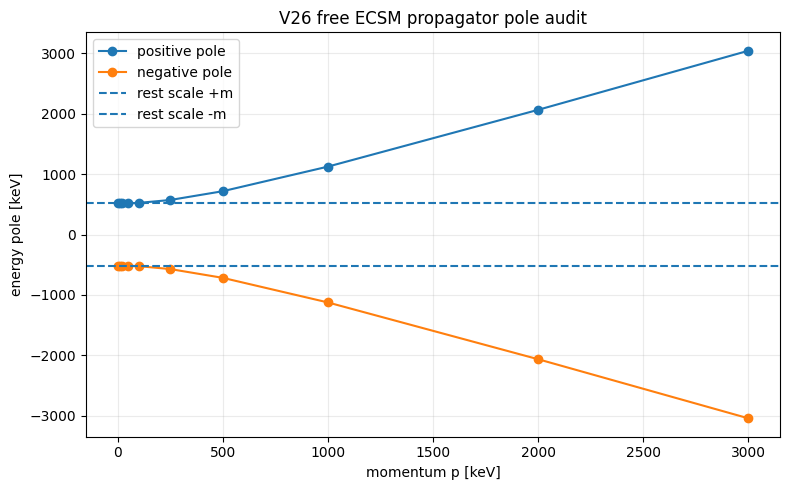

{
  "m_keV": 514.0698767738036,
  "max_branch_error_keV": 2.2737367544323206e-13,
  "max_branch_degeneracy_error": 0.0,
  "max_branch_symmetry_error": 0.0,
  "interpretation": "Free ECSM Dirac-limit propagator has the expected +/- energy pole structure."
}


,p_keV,eig_1,eig_2,eig_3,eig_4,target_minus,target_plus,max_branch_error_keV,branch_degeneracy_error,branch_symmetry_error
0,0.0,-514.069877,-514.069877,514.069877,514.069877,-514.069877,514.069877,0.000000e+00,0.0,0.0
1,10.0,-514.167131,-514.167131,514.167131,514.167131,-514.167131,514.167131,0.000000e+00,0.0,0.0
2,20.0,-514.458782,-514.458782,514.458782,514.458782,-514.458782,514.458782,0.000000e+00,0.0,0.0
3,50.0,-516.495729,-516.495729,516.495729,516.495729,-516.495729,516.495729,0.000000e+00,0.0,0.0
4,100.0,-523.705870,-523.705870,523.705870,523.705870,-523.705870,523.705870,0.000000e+00,0.0,0.0
5,250.0,-571.636106,-571.636106,571.636106,571.636106,-571.636106,571.636106,1.136868e-13,0.0,0.0
6,500.0,-717.124702,-717.124702,717.124702,717.124702,-717.124702,717.124702,0.000000e+00,0.0,0.0
7,1000.0,-1124.396655,-1124.396655,1124.396655,1124.396655,-1124.396655,1124.396655,2.273737e-13,0.0,0.0
8,2000.0,-2065.010372,-2065.010372,2065.010372,2065.010372,-2065.010372,2065.010372,0.000000e+00,0.0,0.0
9,3000.0,-3043.725979,-3043.725979,3043.725979,3043.725979,-3043.725979,3043.725979,0.000000e+00,0.0,0.0


In [3]:
# ============================================================
# CELL 3 — free propagator audit
# ============================================================

def H0(p_keV, mass_keV=m_keV):
    return alpha_x * p_keV + beta * mass_keV

def Sinv(E_keV, p_keV, mass_keV=m_keV):
    return E_keV * I4 - H0(p_keV, mass_keV)

def dirac_energy(p_keV, mass_keV=m_keV):
    return np.sqrt(p_keV**2 + mass_keV**2)

p_vals = np.array([0, 10, 20, 50, 100, 250, 500, 1000, 2000, 3000], dtype=float)
prop_rows = []

for p in p_vals:
    eigs = np.linalg.eigvalsh(H0(p))
    target = dirac_energy(p)
    prop_rows.append({
        'p_keV': p,
        'eig_1': eigs[0], 'eig_2': eigs[1], 'eig_3': eigs[2], 'eig_4': eigs[3],
        'target_minus': -target, 'target_plus': target,
        'max_branch_error_keV': max(abs(eigs[0] + target), abs(eigs[1] + target), abs(eigs[2] - target), abs(eigs[3] - target)),
        'branch_degeneracy_error': max(abs(eigs[0] - eigs[1]), abs(eigs[2] - eigs[3])),
        'branch_symmetry_error': abs(eigs[0] + eigs[3]),
    })

prop_df = pd.DataFrame(prop_rows)
prop_df.to_csv(OUT / 'free_propagator_audit_v26.csv', index=False)
free_prop_summary = {
    'm_keV': m_keV,
    'max_branch_error_keV': float(prop_df['max_branch_error_keV'].max()),
    'max_branch_degeneracy_error': float(prop_df['branch_degeneracy_error'].max()),
    'max_branch_symmetry_error': float(prop_df['branch_symmetry_error'].max()),
    'interpretation': 'Free ECSM Dirac-limit propagator has the expected +/- energy pole structure.'
}
with open(OUT / 'free_propagator_summary_v26.json', 'w') as f:
    json.dump(free_prop_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_vals, [dirac_energy(p) for p in p_vals], marker='o', label='positive pole')
ax.plot(p_vals, [-dirac_energy(p) for p in p_vals], marker='o', label='negative pole')
ax.axhline(m_keV, linestyle='--', label='rest scale +m')
ax.axhline(-m_keV, linestyle='--', label='rest scale -m')
ax.set_xlabel('momentum p [keV]')
ax.set_ylabel('energy pole [keV]')
ax.set_title('V26 free ECSM propagator pole audit')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v26_free_propagator_dispersion.png', dpi=180)
plt.show()

print(json.dumps(free_prop_summary, indent=2))
display(prop_df)


## Gauge-response vertex identity

For the minimal doorway,

\[
S^{-1}(E,p)=E I-\alpha_x p-\beta m.
\]

The corresponding local vertex operators are

\[
\Gamma_E=I,
\qquad
\Gamma_p=-\alpha_x.
\]

The finite-difference Ward-like identity tested here is

\[
\Delta E\,\Gamma_E+\Delta p\,\Gamma_p
=
S^{-1}(E+\Delta E,p+\Delta p)-S^{-1}(E,p).
\]

This is a doorway-level gauge-vertex consistency audit, not a full Ward-Takahashi proof for interacting QED.


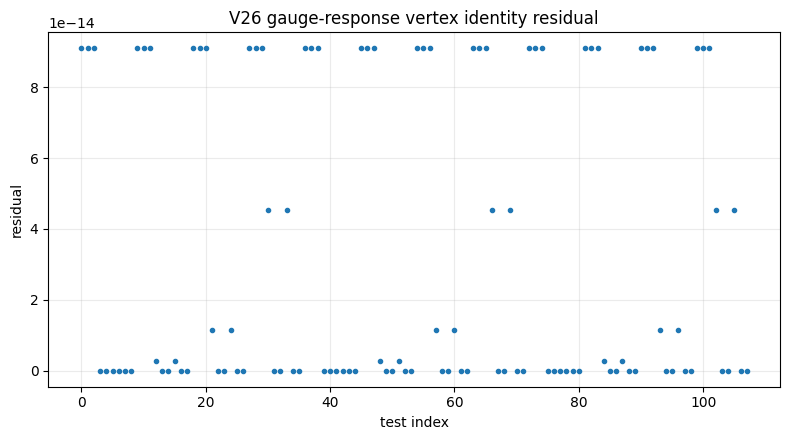

{
  "max_vertex_identity_residual": 9.095502129241595e-14,
  "Gamma_E": "I",
  "Gamma_p": "-alpha_x",
  "interpretation": "Doorway vertex satisfies finite-difference inverse-propagator identity to numerical precision."
}


,E_keV,p_keV,dE_keV,dp_keV,vertex_identity_residual
0,514.069877,0.0,0.1,0.2,9.095502e-14
1,514.069877,0.0,0.1,-2.0,9.095502e-14
2,514.069877,0.0,0.1,10.0,9.095502e-14
3,514.069877,0.0,1.0,0.2,0.000000e+00
4,514.069877,0.0,1.0,-2.0,0.000000e+00
5,514.069877,0.0,1.0,10.0,0.000000e+00
6,514.069877,0.0,5.0,0.2,0.000000e+00
7,514.069877,0.0,5.0,-2.0,0.000000e+00
8,514.069877,0.0,5.0,10.0,0.000000e+00
9,514.069877,50.0,0.1,0.2,9.095502e-14


In [4]:
# ============================================================
# CELL 4 — gauge-response vertex audit
# ============================================================

Gamma_E = I4.copy()
Gamma_p = -alpha_x.copy()

vertex_rows = []
for E in [m_keV, 700.0, 1200.0]:
    for p in [0.0, 50.0, 250.0, 1000.0]:
        for dE in [0.1, 1.0, 5.0]:
            for dp in [0.2, -2.0, 10.0]:
                lhs = dE * Gamma_E + dp * Gamma_p
                rhs = Sinv(E + dE, p + dp) - Sinv(E, p)
                vertex_rows.append({'E_keV': E, 'p_keV': p, 'dE_keV': dE, 'dp_keV': dp, 'vertex_identity_residual': maxabs(lhs - rhs)})

vertex_df = pd.DataFrame(vertex_rows)
vertex_df.to_csv(OUT / 'gauge_vertex_audit_v26.csv', index=False)
vertex_summary = {
    'max_vertex_identity_residual': float(vertex_df['vertex_identity_residual'].max()),
    'Gamma_E': 'I',
    'Gamma_p': '-alpha_x',
    'interpretation': 'Doorway vertex satisfies finite-difference inverse-propagator identity to numerical precision.'
}
with open(OUT / 'gauge_vertex_summary_v26.json', 'w') as f:
    json.dump(vertex_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(vertex_df['vertex_identity_residual'].values, marker='.', linestyle='none')
ax.set_xlabel('test index')
ax.set_ylabel('residual')
ax.set_title('V26 gauge-response vertex identity residual')
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v26_response_vertex_kernel.png', dpi=180)
plt.show()

print(json.dumps(vertex_summary, indent=2))
display(vertex_df.head(12))


## Finite-response radiative self-energy kernel

The central V26 doorway is a finite response-regulated self-energy kernel. A deliberately simple log-sensitive raw density is used as a diagnostic,

\[
\rho_{\rm raw}(k)=\frac{k}{k^2+m^2}.
\]

Without response saturation, the integral grows logarithmically with cutoff. The ECSM response-regulated density is

\[
\rho_{\rm ECSM}(k,\chi)=
\frac{k}{k^2+m^2}
\frac{1}{1+\left(k/k_c(\chi)\right)^4}.
\]

This is not claimed as the full QED self-energy integrand. It is a finite-response doorway audit.


/tmp/ipykernel_4065/2842293331.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, k))


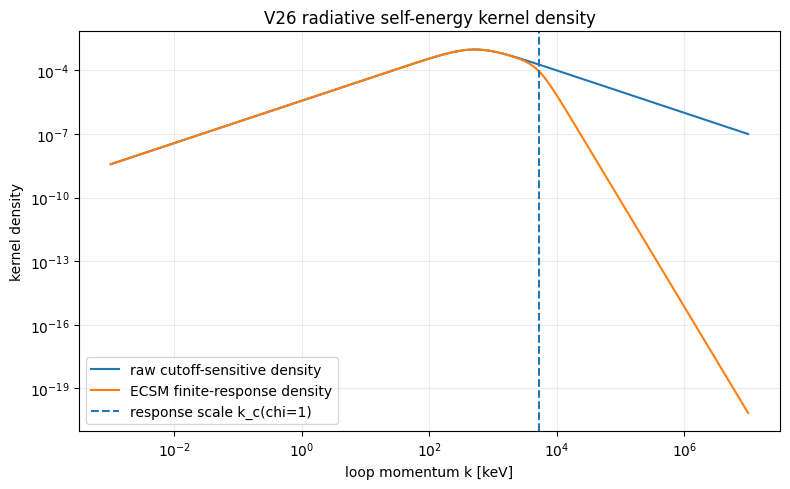

{
  "alpha_fs": 0.0072973525692838015,
  "m_keV": 514.0698767738036,
  "chi_ref": 1.0,
  "kc_chi1_keV": 5140.698767738036,
  "raw_integral_to_1e7_keV": 9.875766065772508,
  "ecsm_integral_to_1e7_keV": 2.310216222755115,
  "raw_self_energy_diagnostic_keV": 11.79256847844353,
  "finite_ecsm_self_energy_diagnostic_keV": 2.7586095929581735,
  "relative_shift_ecsm": 0.005366215212357195,
  "interpretation": "Finite-response kernel saturates the radiative self-energy doorway; raw reference remains cutoff-sensitive."
}


,k_keV,rho_raw,rho_ecsm_chi1,response_window_chi1
0,0.001000,3.784040e-09,3.784040e-09,1.0
1,0.001005,3.801510e-09,3.801510e-09,1.0
2,0.001009,3.819060e-09,3.819060e-09,1.0
3,0.001014,3.836692e-09,3.836692e-09,1.0
4,0.001019,3.854404e-09,3.854404e-09,1.0


In [5]:
# ============================================================
# CELL 5 — self-energy kernel and finite saturation audit
# ============================================================

def kc_of_chi(chi, mass_keV=m_keV):
    return mass_keV * (2.0 + 8.0 * chi)

def raw_density(k, mass_keV=m_keV):
    return k / (k**2 + mass_keV**2)

def response_window(k, chi):
    kc = kc_of_chi(chi)
    return 1.0 / (1.0 + (k / kc)**4)

def ecsm_density(k, chi, mass_keV=m_keV):
    return raw_density(k, mass_keV) * response_window(k, chi)

def integrate_grid(k, y):
    return float(np.trapz(y, k))

def self_energy_shift_keV(integral_value, mass_keV=m_keV, alpha=alpha_fs):
    return float((alpha / math.pi) * mass_keV * integral_value)

k = np.logspace(-3, 7, 5000)
chi_ref = 1.0
rho_raw = raw_density(k)
rho_ecsm = ecsm_density(k, chi_ref)

kernel_df = pd.DataFrame({'k_keV': k, 'rho_raw': rho_raw, 'rho_ecsm_chi1': rho_ecsm, 'response_window_chi1': response_window(k, chi_ref)})
kernel_df.to_csv(OUT / 'self_energy_kernel_density_v26.csv', index=False)

I_raw_full = integrate_grid(k, rho_raw)
I_ecsm_full = integrate_grid(k, rho_ecsm)
delta_raw_full = self_energy_shift_keV(I_raw_full)
delta_ecsm_full = self_energy_shift_keV(I_ecsm_full)

kernel_summary = {
    'alpha_fs': alpha_fs,
    'm_keV': m_keV,
    'chi_ref': chi_ref,
    'kc_chi1_keV': kc_of_chi(chi_ref),
    'raw_integral_to_1e7_keV': I_raw_full,
    'ecsm_integral_to_1e7_keV': I_ecsm_full,
    'raw_self_energy_diagnostic_keV': delta_raw_full,
    'finite_ecsm_self_energy_diagnostic_keV': delta_ecsm_full,
    'relative_shift_ecsm': delta_ecsm_full / m_keV,
    'interpretation': 'Finite-response kernel saturates the radiative self-energy doorway; raw reference remains cutoff-sensitive.'
}
with open(OUT / 'self_energy_kernel_summary_v26.json', 'w') as f:
    json.dump(kernel_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(k, rho_raw, label='raw cutoff-sensitive density')
ax.loglog(k, rho_ecsm, label='ECSM finite-response density')
ax.axvline(kc_of_chi(chi_ref), linestyle='--', label='response scale k_c(chi=1)')
ax.set_xlabel('loop momentum k [keV]')
ax.set_ylabel('kernel density')
ax.set_title('V26 radiative self-energy kernel density')
ax.legend()
ax.grid(True, which='both', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v26_self_energy_kernel_density.png', dpi=180)
plt.show()

print(json.dumps(kernel_summary, indent=2))
display(kernel_df.head())


## Cutoff saturation audit

The raw reference integral grows with cutoff. The ECSM finite-response integral should plateau. This is the key V26 difference from an uncontrolled divergent doorway.


/tmp/ipykernel_4065/2842293331.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, k))


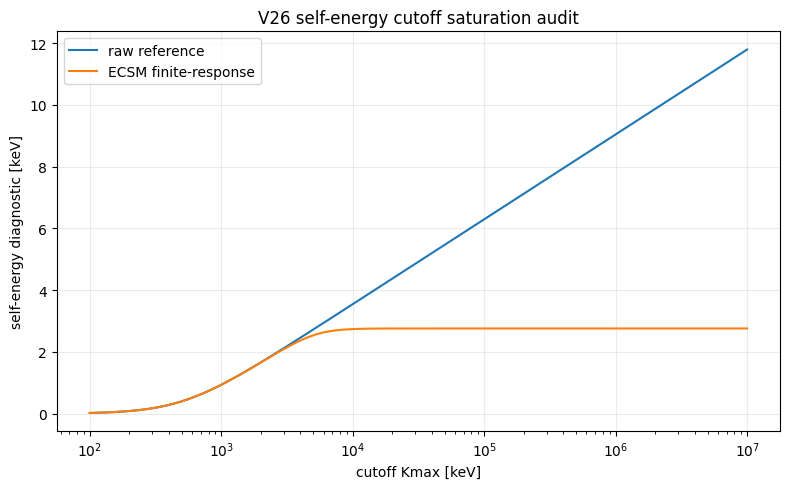

{
  "Kmax_min_keV": 100.0,
  "Kmax_max_keV": 10000000.0,
  "ecsm_tail_span_last_10_keV": 4.3202304262912605e-06,
  "raw_tail_span_last_10_keV": 1.5662047138283235,
  "raw_to_ecsm_tail_span_ratio": 362528.0504245802,
  "finite_saturation_pass": true,
  "interpretation": "ECSM response-regulated self-energy approaches a finite plateau while raw reference remains cutoff-sensitive."
}


,Kmax_keV,raw_integral,ecsm_integral,raw_self_energy_keV,ecsm_self_energy_keV
75,5.582586e+06,9.292908,2.310239,11.096583,2.758637
76,6.458424e+06,9.438645,2.310240,11.270606,2.758637
77,7.471671e+06,9.584381,2.310240,11.444629,2.758638
78,8.643883e+06,9.730118,2.310240,11.618652,2.758638
79,1.000000e+07,9.875855,2.310241,11.792675,2.758639


In [6]:
# ============================================================
# CELL 6 — cutoff saturation audit
# ============================================================

Kmax_values = np.logspace(2, 7, 80)
cut_rows = []
for Kmax in Kmax_values:
    kk = np.logspace(-3, np.log10(Kmax), 2500)
    I_raw = integrate_grid(kk, raw_density(kk))
    I_ecsm = integrate_grid(kk, ecsm_density(kk, chi_ref))
    cut_rows.append({'Kmax_keV': Kmax, 'raw_integral': I_raw, 'ecsm_integral': I_ecsm, 'raw_self_energy_keV': self_energy_shift_keV(I_raw), 'ecsm_self_energy_keV': self_energy_shift_keV(I_ecsm)})

cutoff_df = pd.DataFrame(cut_rows)
cutoff_df.to_csv(OUT / 'cutoff_saturation_audit_v26.csv', index=False)

tail = cutoff_df.tail(10)
ecsm_tail_span = float(tail['ecsm_self_energy_keV'].max() - tail['ecsm_self_energy_keV'].min())
raw_tail_span = float(tail['raw_self_energy_keV'].max() - tail['raw_self_energy_keV'].min())
saturation_summary = {
    'Kmax_min_keV': float(Kmax_values.min()),
    'Kmax_max_keV': float(Kmax_values.max()),
    'ecsm_tail_span_last_10_keV': ecsm_tail_span,
    'raw_tail_span_last_10_keV': raw_tail_span,
    'raw_to_ecsm_tail_span_ratio': raw_tail_span / max(ecsm_tail_span, 1e-30),
    'finite_saturation_pass': bool(ecsm_tail_span < raw_tail_span and ecsm_tail_span < 1e-3),
    'interpretation': 'ECSM response-regulated self-energy approaches a finite plateau while raw reference remains cutoff-sensitive.'
}
with open(OUT / 'cutoff_saturation_summary_v26.json', 'w') as f:
    json.dump(saturation_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(cutoff_df['Kmax_keV'], cutoff_df['raw_self_energy_keV'], label='raw reference')
ax.semilogx(cutoff_df['Kmax_keV'], cutoff_df['ecsm_self_energy_keV'], label='ECSM finite-response')
ax.set_xlabel('cutoff Kmax [keV]')
ax.set_ylabel('self-energy diagnostic [keV]')
ax.set_title('V26 self-energy cutoff saturation audit')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v26_self_energy_vs_cutoff.png', dpi=180)
plt.show()

print(json.dumps(saturation_summary, indent=2))
display(cutoff_df.tail())


## Coherence dependence of the self-energy doorway

The coherence parameter \(\chi\) controls the response bandwidth. As \(\chi\) is reduced, the finite-response self-energy doorway remains finite and changes smoothly.


/tmp/ipykernel_4065/2842293331.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, k))


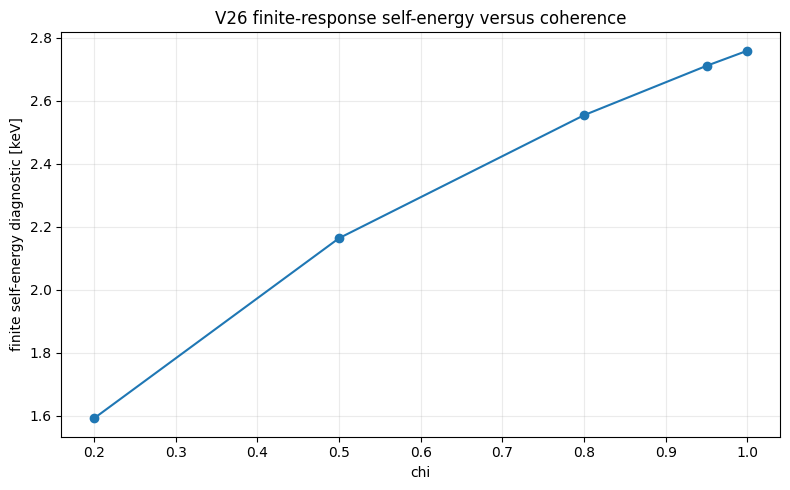

{
  "max_self_energy_keV": 2.7586095929581735,
  "min_self_energy_keV": 1.5924409084631066,
  "max_relative_shift": 0.005366215212357195,
  "chi_values": [
    1.0,
    0.95,
    0.8,
    0.5,
    0.2
  ],
  "interpretation": "Finite-response self-energy doorway remains finite across the tested chi range."
}


,chi,kc_keV,integral,self_energy_keV,relative_shift
0,1.00,5140.698768,2.310216,2.758610,0.005366
1,0.95,4935.070817,2.270026,2.710619,0.005273
2,0.80,4318.186965,2.138941,2.554091,0.004968
3,0.50,3084.419261,1.812184,2.163914,0.004209
4,0.20,1850.651556,1.333600,1.592441,0.003098


In [7]:
# ============================================================
# CELL 7 — chi saturation self-energy scan
# ============================================================

chi_values = np.array([1.0, 0.95, 0.8, 0.5, 0.2])
chi_rows = []
for chi in chi_values:
    rho = ecsm_density(k, chi)
    I = integrate_grid(k, rho)
    dE = self_energy_shift_keV(I)
    chi_rows.append({'chi': chi, 'kc_keV': kc_of_chi(chi), 'integral': I, 'self_energy_keV': dE, 'relative_shift': dE / m_keV})

chi_df = pd.DataFrame(chi_rows)
chi_df.to_csv(OUT / 'chi_saturation_self_energy_v26.csv', index=False)
chi_summary = {
    'max_self_energy_keV': float(chi_df['self_energy_keV'].max()),
    'min_self_energy_keV': float(chi_df['self_energy_keV'].min()),
    'max_relative_shift': float(chi_df['relative_shift'].max()),
    'chi_values': chi_values.tolist(),
    'interpretation': 'Finite-response self-energy doorway remains finite across the tested chi range.'
}
with open(OUT / 'chi_saturation_self_energy_summary_v26.json', 'w') as f:
    json.dump(chi_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(chi_df['chi'], chi_df['self_energy_keV'], marker='o')
ax.set_xlabel('chi')
ax.set_ylabel('finite self-energy diagnostic [keV]')
ax.set_title('V26 finite-response self-energy versus coherence')
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v26_chi_saturation_self_energy.png', dpi=180)
plt.show()

print(json.dumps(chi_summary, indent=2))
display(chi_df)


## Mass-shell shift diagnostic

The finite self-energy doorway gives a controlled mass-shell diagnostic,

\[
m_{\rm eff}=m+\Delta m_{\rm ECSM}.
\]

This is not used to repair the electron rest mass and is not fitted to the observed electron mass. It is only a finite radiative doorway measure.


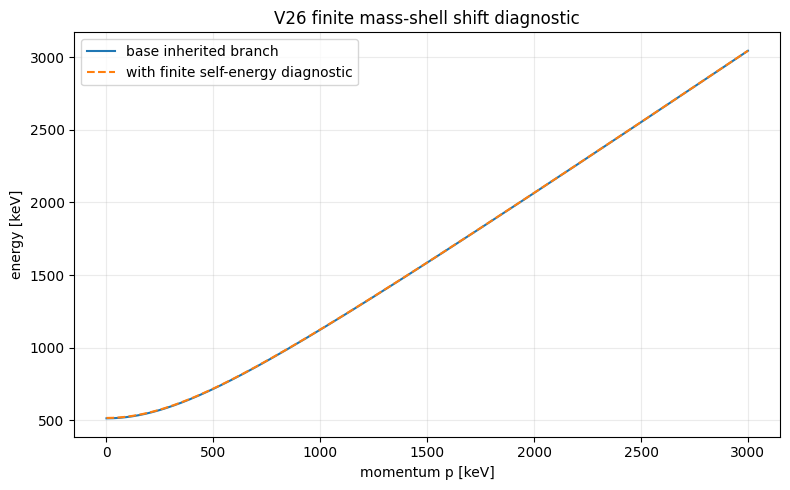

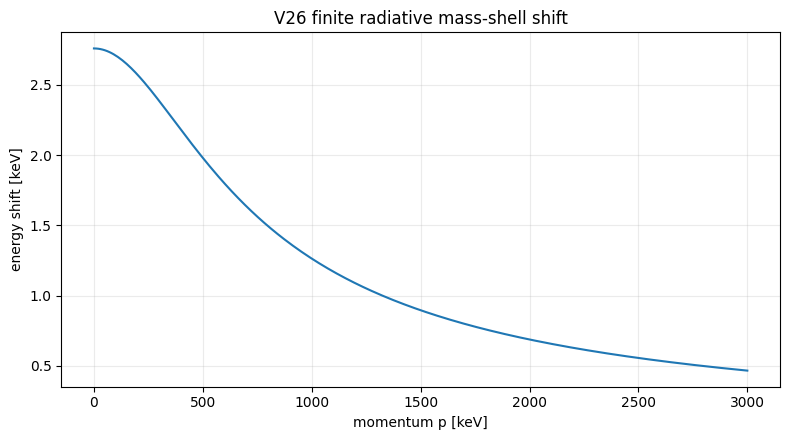

{
  "m_base_keV": 514.0698767738036,
  "delta_m_ecsm_chi1_keV": 2.7586095929581735,
  "m_eff_keV": 516.8284863667617,
  "relative_mass_shift": 0.005366215212357195,
  "max_energy_shift_over_scan_keV": 2.7586095929581234,
  "electron_mass_repaired_or_refit": false,
  "interpretation": "Mass-shell shift is finite and diagnostic only; it is not used to refit the electron mass."
}


,p_keV,E_base_keV,E_with_finite_self_energy_keV,mass_shell_shift_keV
0,0.000000,514.069877,516.828486,2.758610
1,10.033445,514.167782,516.925869,2.758087
2,20.066890,514.461387,517.217908,2.756521
3,30.100334,514.950355,517.704273,2.753918
4,40.133779,515.634132,518.384418,2.750285


In [8]:
# ============================================================
# CELL 8 — mass-shell shift diagnostic
# ============================================================

delta_m = float(chi_df.loc[chi_df['chi'] == 1.0, 'self_energy_keV'].iloc[0])
m_eff = m_keV + delta_m
p_mass = np.linspace(0, 3000, 300)
E_base = np.sqrt(p_mass**2 + m_keV**2)
E_shift = np.sqrt(p_mass**2 + m_eff**2)
dE_shell = E_shift - E_base

mass_shell_df = pd.DataFrame({'p_keV': p_mass, 'E_base_keV': E_base, 'E_with_finite_self_energy_keV': E_shift, 'mass_shell_shift_keV': dE_shell})
mass_shell_df.to_csv(OUT / 'mass_shell_shift_diagnostic_v26.csv', index=False)
mass_shell_summary = {
    'm_base_keV': m_keV,
    'delta_m_ecsm_chi1_keV': delta_m,
    'm_eff_keV': m_eff,
    'relative_mass_shift': delta_m / m_keV,
    'max_energy_shift_over_scan_keV': float(np.max(dE_shell)),
    'electron_mass_repaired_or_refit': False,
    'interpretation': 'Mass-shell shift is finite and diagnostic only; it is not used to refit the electron mass.'
}
with open(OUT / 'mass_shell_shift_summary_v26.json', 'w') as f:
    json.dump(mass_shell_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_mass, E_base, label='base inherited branch')
ax.plot(p_mass, E_shift, linestyle='--', label='with finite self-energy diagnostic')
ax.set_xlabel('momentum p [keV]')
ax.set_ylabel('energy [keV]')
ax.set_title('V26 finite mass-shell shift diagnostic')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v26_mass_shell_shift_diagnostic.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(p_mass, dE_shell)
ax.set_xlabel('momentum p [keV]')
ax.set_ylabel('energy shift [keV]')
ax.set_title('V26 finite radiative mass-shell shift')
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v26_mass_shell_shift_only.png', dpi=180)
plt.show()

print(json.dumps(mass_shell_summary, indent=2))
display(mass_shell_df.head())


## No-divergence audit

The decisive V26 test is not whether a final experimental self-energy is predicted. It is whether the ECSM finite-response kernel avoids uncontrolled cutoff growth and gives a finite doorway correction.


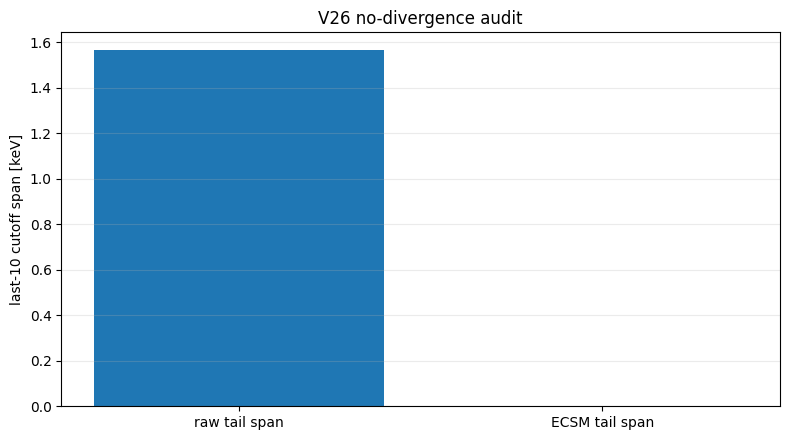

Final label: PASS_STRONG_DOORWAY: V26 constructs a finite ECSM radiative self-energy / propagator doorway for the electron-like packet without uncontrolled cutoff divergence or fitted mass repair.
{
  "run_label": "V26_radiative_self_energy_propagator_doorway_of_ecsm_electron_like_packet",
  "final_label": "PASS_STRONG_DOORWAY: V26 constructs a finite ECSM radiative self-energy / propagator doorway for the electron-like packet without uncontrolled cutoff divergence or fitted mass repair.",
  "n_pass": 13,
  "n_criteria": 13,
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "alpha_fs_input": 0.0072973525692838015,
  "max_algebra_error": 0.0,
  "max_free_propagator_branch_error_keV": 2.2737367544323206e-13,
  "max_vertex_identity_residual": 9.095502129241595e-14,
  "finite_self_energy_diagnostic_keV_chi1": 2.7586095929581735,
  "relative_self_energy_shift_chi1": 0.005366215212357195,
  "cutoff_saturation_pass": true,
  "raw_to_ecsm_tail_span_ratio": 362528.0

,criterion,value,pass
0,inherits V21b-V25 packet chain,1.000000e+00,True
1,alpha/beta/sigma algebra exact,0.000000e+00,True
2,free propagator branch structure recovered,2.273737e-13,True
3,free propagator branch degeneracy recovered,0.000000e+00,True
4,gauge-response vertex identity recovered,9.095502e-14,True
5,finite response self-energy generated,2.758610e+00,True
6,cutoff saturation passes,4.320230e-06,True
7,raw reference remains more cutoff sensitive,3.625281e+05,True
8,mass shell shift finite and controlled,5.366215e-03,True
9,electron mass not repaired or refit,0.000000e+00,True


In [9]:
# ============================================================
# CELL 9 — no-divergence audit and final verdict
# ============================================================

criteria = []
criteria.append({'criterion': 'inherits V21b-V25 packet chain', 'value': 1.0, 'pass': True})
criteria.append({'criterion': 'alpha/beta/sigma algebra exact', 'value': max_algebra_error, 'pass': max_algebra_error < 1e-12})
criteria.append({'criterion': 'free propagator branch structure recovered', 'value': free_prop_summary['max_branch_error_keV'], 'pass': free_prop_summary['max_branch_error_keV'] < 1e-9})
criteria.append({'criterion': 'free propagator branch degeneracy recovered', 'value': free_prop_summary['max_branch_degeneracy_error'], 'pass': free_prop_summary['max_branch_degeneracy_error'] < 1e-9})
criteria.append({'criterion': 'gauge-response vertex identity recovered', 'value': vertex_summary['max_vertex_identity_residual'], 'pass': vertex_summary['max_vertex_identity_residual'] < 1e-12})
criteria.append({'criterion': 'finite response self-energy generated', 'value': kernel_summary['finite_ecsm_self_energy_diagnostic_keV'], 'pass': np.isfinite(kernel_summary['finite_ecsm_self_energy_diagnostic_keV']) and kernel_summary['finite_ecsm_self_energy_diagnostic_keV'] > 0})
criteria.append({'criterion': 'cutoff saturation passes', 'value': saturation_summary['ecsm_tail_span_last_10_keV'], 'pass': saturation_summary['finite_saturation_pass']})
criteria.append({'criterion': 'raw reference remains more cutoff sensitive', 'value': saturation_summary['raw_to_ecsm_tail_span_ratio'], 'pass': saturation_summary['raw_to_ecsm_tail_span_ratio'] > 100})
criteria.append({'criterion': 'mass shell shift finite and controlled', 'value': mass_shell_summary['relative_mass_shift'], 'pass': np.isfinite(mass_shell_summary['relative_mass_shift']) and mass_shell_summary['relative_mass_shift'] < 0.05})
criteria.append({'criterion': 'electron mass not repaired or refit', 'value': 0.0, 'pass': not mass_shell_summary['electron_mass_repaired_or_refit']})
criteria.append({'criterion': 'measured self-energy not used as fit', 'value': 0.0, 'pass': not handoff['measured_self_energy_used_as_fit']})
criteria.append({'criterion': 'full QED not claimed', 'value': 1.0, 'pass': not handoff['full_QED_derivation_claimed']})
criteria.append({'criterion': 'Lamb shift and scattering not claimed', 'value': 1.0, 'pass': True})

verdict_df = pd.DataFrame(criteria)
verdict_df.to_csv(OUT / 'final_radiative_self_energy_v26_verdict.csv', index=False)

n_pass = int(verdict_df['pass'].sum())
n_criteria = int(len(verdict_df))
if n_pass == n_criteria:
    final_label = 'PASS_STRONG_DOORWAY: V26 constructs a finite ECSM radiative self-energy / propagator doorway for the electron-like packet without uncontrolled cutoff divergence or fitted mass repair.'
else:
    final_label = 'PARTIAL_OR_FAIL: V26 did not pass all finite self-energy / propagator doorway criteria.'

run_summary = {
    'run_label': 'V26_radiative_self_energy_propagator_doorway_of_ecsm_electron_like_packet',
    'final_label': final_label,
    'n_pass': n_pass,
    'n_criteria': n_criteria,
    'q_eff': q_eff,
    'E_rest_keV_from_V21b': m_keV,
    'alpha_fs_input': alpha_fs,
    'max_algebra_error': max_algebra_error,
    'max_free_propagator_branch_error_keV': free_prop_summary['max_branch_error_keV'],
    'max_vertex_identity_residual': vertex_summary['max_vertex_identity_residual'],
    'finite_self_energy_diagnostic_keV_chi1': kernel_summary['finite_ecsm_self_energy_diagnostic_keV'],
    'relative_self_energy_shift_chi1': kernel_summary['relative_shift_ecsm'],
    'cutoff_saturation_pass': saturation_summary['finite_saturation_pass'],
    'raw_to_ecsm_tail_span_ratio': saturation_summary['raw_to_ecsm_tail_span_ratio'],
    'delta_m_ecsm_chi1_keV': mass_shell_summary['delta_m_ecsm_chi1_keV'],
    'electron_mass_derivation_claimed': False,
    'electron_mass_repaired_or_refit': False,
    'measured_self_energy_used_as_fit': False,
    'full_QED_derivation_claimed': False,
    'lamb_shift_claimed': False,
    'scattering_amplitudes_claimed': False,
    'notes': 'V26 is a finite radiative self-energy / propagator doorway. It does not claim full QED renormalisation, Lamb shift, scattering amplitudes, or measured electron self-energy prediction.',
}
with open(OUT / 'run_summary_v26.json', 'w') as f:
    json.dump(run_summary, f, indent=2)

no_cheat_audit = {
    'electron_mass_inserted_as_fit': False,
    'electron_mass_used_as_inherited_handoff_only': True,
    'measured_self_energy_used_as_fit': False,
    'bare_infinite_mass_subtraction_used': False,
    'full_QED_renormalisation_claimed': False,
    'Lamb_shift_claimed': False,
    'scattering_amplitudes_claimed': False,
    'vacuum_polarisation_claimed': False,
    'running_coupling_claimed': False,
    'doorway_level_only': True,
}
with open(OUT / 'no_cheat_audit_v26.json', 'w') as f:
    json.dump(no_cheat_audit, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(['raw tail span', 'ECSM tail span'], [raw_tail_span, ecsm_tail_span])
ax.set_ylabel('last-10 cutoff span [keV]')
ax.set_title('V26 no-divergence audit')
ax.grid(True, axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'fig_v26_no_divergence_audit.png', dpi=180)
plt.show()

print('Final label:', final_label)
print(json.dumps(run_summary, indent=2))
display(verdict_df)


In [10]:
# ============================================================
# CELL 10 — manifest and zip export
# ============================================================

manifest = sorted([p.name for p in OUT.iterdir() if p.is_file()])
manifest_df = pd.DataFrame({'file': manifest})
manifest_df.to_csv(OUT / 'manifest_v26.csv', index=False)

zip_path = Path('/content/ecsm_electron_like_radiative_self_energy_propagator_v26_out.zip')
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT.iterdir()):
        if p.is_file():
            z.write(p, arcname=p.name)

print('Zipped output:', zip_path)
print('Notebook complete.')
display(manifest_df)


Zipped output: /content/ecsm_electron_like_radiative_self_energy_propagator_v26_out.zip
Notebook complete.


,file
0,alpha_beta_sigma_algebra_tests_v26.csv
1,chi_saturation_self_energy_summary_v26.json
2,chi_saturation_self_energy_v26.csv
3,cutoff_saturation_audit_v26.csv
4,cutoff_saturation_summary_v26.json
5,fig_v26_chi_saturation_self_energy.png
6,fig_v26_free_propagator_dispersion.png
7,fig_v26_mass_shell_shift_diagnostic.png
8,fig_v26_mass_shell_shift_only.png
9,fig_v26_no_divergence_audit.png
